## Function 3 — Week 9: SFGP with qLogNEI Acquisition (15 MLL Restarts)

This notebook processes the **Week 9** updated data for Function 3 and proposes the next sample point using the same strategy as Week 8:

- **Surrogate**: Single-Fidelity GP with Matérn-2.5 kernel, ARD (3 lengthscales), noise ≥ 1e-6, manual z-score output standardisation
- **Training**: 15-restart MLL optimisation with `torch.manual_seed` seeding and `copy.deepcopy` best model selection
- **Acquisition**: qLogNoisyExpectedImprovement (qLogNEI) — 10 restarts, 512 raw samples
- **Data**: 24 cumulative samples (15 initial + 9 weekly)

**Enhancements in Week 9**:
- **Three-colour visualisation**: Initial samples (blue), weekly submissions (orange), proposed next point (green star)
- **Performance evaluation**: Convergence metrics, exploration spread analysis, LOO surrogate error, and strategy interpretation

In [1]:
import copy
import warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.constraints import GreaterThan
from gpytorch.likelihoods import GaussianLikelihood
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf

print("All imports successful.")

All imports successful.


### Hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Kernel | Matérn-2.5 | Smoother than 1.5; suitable for compound mixture landscapes |
| ARD dims | 3 | One lengthscale per compound (A, B, C) |
| Noise floor | 1e-6 | Tight noise constraint for relatively clean outputs |
| N_RESTARTS (MLL) | 15 | Multi-restart MLL to escape local optima in hyperparameter space |
| LENGTHSCALE_INIT | 0.25 | Starting lengthscale for each restart |
| SIGNAL_VAR_INIT | 1.0 | Starting outputscale |
| NOISE_VAR_INIT | 0.1 | Starting noise variance |
| N_RESTARTS (acq) | 10 | Multi-start for acquisition optimisation |
| RAW_SAMPLES | 512 | Sobol candidate pool |

In [2]:
# ─── Data Shape ────────────────────────────────────────────────────────────────
N_INITIAL   = 15
N_TOTAL     = 24          # 15 initial + 9 weekly
N_DIMS      = 3
N_SUBMISSIONS = N_TOTAL - N_INITIAL
DIM         = N_DIMS
DIM_NAMES   = ['Compound A', 'Compound B', 'Compound C']

# ─── Constants (identical to Week 8) ──────────────────────────────────────────
N_RESTARTS       = 15    # MLL restarts
LENGTHSCALE_INIT = 0.25
SIGNAL_VAR_INIT  = 1.0
NOISE_VAR_INIT   = 0.1
JITTER           = 1e-6

# Acquisition constants
ACQ_RESTARTS  = 10
ACQ_RAW       = 512
BOUNDS = torch.tensor([[0.0, 0.0, 0.0],
                        [0.999999, 0.999999, 0.999999]], dtype=torch.float64)

# ─── Performance Evaluation Constants ─────────────────────────────────────────
STALLING_CONSECUTIVE_THRESHOLD = 3
STALLING_RELATIVE_THRESHOLD    = 0.05

print("Week 9 Constants:")
print(f"  N_INITIAL:     {N_INITIAL}")
print(f"  N_TOTAL:       {N_TOTAL}")
print(f"  N_SUBMISSIONS: {N_SUBMISSIONS}")
print(f"  N_RESTARTS (MLL):  {N_RESTARTS}")
print(f"  LENGTHSCALE_INIT:  {LENGTHSCALE_INIT}")
print(f"  SIGNAL_VAR_INIT:   {SIGNAL_VAR_INIT}")
print(f"  NOISE_VAR_INIT:    {NOISE_VAR_INIT}")
print(f"  ACQ_RESTARTS:      {ACQ_RESTARTS}")
print(f"  ACQ_RAW:           {ACQ_RAW}")
print(f"  Stalling threshold (consecutive): {STALLING_CONSECUTIVE_THRESHOLD}")
print(f"  Stalling threshold (relative):    {STALLING_RELATIVE_THRESHOLD}")

Week 9 Constants:
  N_INITIAL:     15
  N_TOTAL:       24
  N_SUBMISSIONS: 9
  N_RESTARTS (MLL):  15
  LENGTHSCALE_INIT:  0.25
  SIGNAL_VAR_INIT:   1.0
  NOISE_VAR_INIT:    0.1
  ACQ_RESTARTS:      10
  ACQ_RAW:           512
  Stalling threshold (consecutive): 3
  Stalling threshold (relative):    0.05


### Step 1: Load Week 9 Data

Load the cumulative Week 9 data (24 total samples = 15 initial + 9 weekly). Apply manual z-score output standardisation. Split into initial/submission subsets.

In [3]:
# Load Week 9 cumulative data
X_raw = np.load('../../data/f3/updated_inputs - Week 9.npy')
y_raw = np.load('../../data/f3/updated_outputs - Week 9.npy')

# Validate dimensions and ranges
assert X_raw.shape == (N_TOTAL, N_DIMS), f"Expected ({N_TOTAL}, {N_DIMS}), got {X_raw.shape}"
assert y_raw.shape == (N_TOTAL,), f"Expected ({N_TOTAL},), got {y_raw.shape}"
assert np.all((X_raw >= 0.0) & (X_raw <= 1.0)), "Inputs out of [0, 1] range"
assert not np.any(np.isnan(y_raw)), "Outputs contain NaN"

# Split into initial samples and weekly submissions
X_initial = X_raw[:N_INITIAL]
y_initial = y_raw[:N_INITIAL]
X_submissions = X_raw[N_INITIAL:]
y_submissions = y_raw[N_INITIAL:]

assert X_submissions.shape[0] == N_SUBMISSIONS, (
    f"Expected {N_SUBMISSIONS} submissions, got {X_submissions.shape[0]}"
)

# Manual z-score output standardisation
y_mean = y_raw.mean()
y_std  = y_raw.std()
y_std_safe = max(y_std, 1e-8)
y_standardised = (y_raw - y_mean) / y_std_safe

# Convert to tensors
X_train = torch.tensor(X_raw, dtype=torch.float64)
Y_train = torch.tensor(y_standardised, dtype=torch.float64).unsqueeze(-1)

print(f"Week 9 Data: {X_raw.shape[0]} samples, {X_raw.shape[1]} dimensions")
print(f"  Initial samples:    {len(y_initial)}")
print(f"  Weekly submissions: {len(y_submissions)}")
print(f"Output range (raw):          [{y_raw.min():.6f}, {y_raw.max():.6f}]")
print(f"Output range (standardised): [{y_standardised.min():.6f}, {y_standardised.max():.6f}]")
print(f"y_mean={y_mean:.6f}, y_std={y_std:.6f}")
print(f"Best observed value: {y_raw.max():.6f} at index {y_raw.argmax()}")
print(f"Best observed point: {X_raw[y_raw.argmax()]}")

# Per-dimension ranges with compound labels
print(f"\nPer-dimension ranges:")
for d in range(DIM):
    print(f"  {DIM_NAMES[d]:>12}: [{X_raw[:, d].min():.6f}, {X_raw[:, d].max():.6f}]")

# Display tabular data
print(f"\n{'Idx':>4}  {'Type':>8}  {'Compound A':>10}  {'Compound B':>10}  {'Compound C':>10}  {'y (raw)':>12}")
print("-" * 65)
for i in range(len(y_raw)):
    marker = " ← best" if i == y_raw.argmax() else ""
    src = "initial" if i < N_INITIAL else f"wk{i - N_INITIAL + 1}"
    print(f"{i:>4}  {src:>8}  {X_raw[i,0]:>10.6f}  {X_raw[i,1]:>10.6f}  {X_raw[i,2]:>10.6f}  {y_raw[i]:>12.6f}{marker}")

Week 9 Data: 24 samples, 3 dimensions
  Initial samples:    15
  Weekly submissions: 9
Output range (raw):          [-0.398926, -0.031427]
Output range (standardised): [-4.067187, 0.757380]
y_mean=-0.089119, y_std=0.076172
Best observed value: -0.031427 at index 21
Best observed point: [0.063229 0.711381 0.36739 ]

Per-dimension ranges:
    Compound A: [0.016095, 1.000000]
    Compound B: [0.035487, 0.999999]
    Compound C: [0.014859, 0.990882]

 Idx      Type  Compound A  Compound B  Compound C       y (raw)
-----------------------------------------------------------------
   0   initial    0.171525    0.343917    0.248737     -0.112122
   1   initial    0.242114    0.644074    0.272433     -0.087963
   2   initial    0.534906    0.398501    0.173389     -0.111415
   3   initial    0.492581    0.611593    0.340176     -0.034835
   4   initial    0.134622    0.219917    0.458206     -0.048008
   5   initial    0.345523    0.941360    0.269363     -0.110621
   6   initial    0.151837  

### Step 2: Fit Surrogate — 15-Restart MLL Training

SingleTaskGP with `ScaleKernel(MaternKernel(ν=2.5, ard_num_dims=3))` and `GaussianLikelihood(noise ≥ 1e-6)`.
Each restart re-initialises hyperparameters and selects the model with the lowest negative MLL.

In [4]:
best_mll_value = float('inf')
best_model = None

for restart in range(N_RESTARTS):
    torch.manual_seed(restart)
    
    # Build fresh model each restart
    likelihood = GaussianLikelihood(
        noise_constraint=GreaterThan(JITTER)
    )
    covar_module = ScaleKernel(
        MaternKernel(nu=2.5, ard_num_dims=DIM)
    )
    model_i = SingleTaskGP(
        X_train, Y_train,
        covar_module=covar_module,
        likelihood=likelihood,
    )
    
    # Initialise hyperparameters
    model_i.covar_module.base_kernel.lengthscale = torch.tensor([[LENGTHSCALE_INIT] * DIM])
    model_i.covar_module.outputscale = torch.tensor(SIGNAL_VAR_INIT)
    model_i.likelihood.noise_covar.noise = torch.tensor([NOISE_VAR_INIT])
    
    mll_i = ExactMarginalLogLikelihood(model_i.likelihood, model_i)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            fit_gpytorch_mll(mll_i)
        except Exception as e:
            print(f"  Restart {restart:>2}: FAILED — {e}")
            continue
    
    # Evaluate negative MLL
    model_i.eval()
    with torch.no_grad():
        output = model_i(X_train)
        neg_mll = -mll_i(output, Y_train.squeeze(-1)).item()
    
    if neg_mll < best_mll_value:
        best_mll_value = neg_mll
        best_model = copy.deepcopy(model_i)
        print(f"  Restart {restart:>2}: neg_mll = {neg_mll:.4f}  ← new best")
    else:
        print(f"  Restart {restart:>2}: neg_mll = {neg_mll:.4f}")

assert best_model is not None, "All restarts failed!"
model = best_model
model.eval()

# Report final hyperparameters
ls = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
noise = model.likelihood.noise_covar.noise.detach().item()
outputscale = model.covar_module.outputscale.detach().item()

print(f"\nBest model (neg_mll = {best_mll_value:.4f}):")
print(f"  Lengthscales: {', '.join(f'{DIM_NAMES[d]}={ls[d]:.4f}' for d in range(DIM))}")
print(f"  Output scale: {outputscale:.4f}")
print(f"  Noise:        {noise:.6f}")

/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning:

  Restart  0: neg_mll = -0.8712  ← new best
  Restart  1: neg_mll = -0.8712
  Restart  2: neg_mll = -0.8712
  Restart  3: neg_mll = -0.8712
  Restart  4: neg_mll = -0.8712


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning:

  Restart  5: neg_mll = -0.8712
  Restart  6: neg_mll = -0.8712
  Restart  7: neg_mll = -0.8712
  Restart  8: neg_mll = -0.8712
  Restart  9: neg_mll = -0.8712
  Restart 10: neg_mll = -0.8712
  Restart 11: neg_mll = -0.8712
  Restart 12: neg_mll = -0.8712
  Restart 13: neg_mll = -0.8712
  Restart 14: neg_mll = -0.8712

Best model (neg_mll = -0.8712):
  Lengthscales: Compound A=29018.9263, Compound B=2431.8776, Compound C=0.1839
  Output scale: 7.0827
  Noise:        0.011940


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning:

### Step 3: Optimise Acquisition — qLogNoisyExpectedImprovement

`qLogNEI` with `X_baseline` set to training data and `prune_baseline=True`.

In [5]:
# Build qLogNEI acquisition function
nei = qLogNoisyExpectedImprovement(
    model=model,
    X_baseline=X_train,
    prune_baseline=True,
)

# Optimise bounds
bounds_t = torch.tensor(BOUNDS, dtype=torch.float64)

candidate, acq_value = optimize_acqf(
    acq_function=nei,
    bounds=bounds_t,
    q=1,
    num_restarts=ACQ_RESTARTS,
    raw_samples=ACQ_RAW,
)

next_x = candidate.detach().squeeze().numpy()
print(f"Acquisition value: {acq_value.item():.6f}")
print(f"\nProposed next sample:")
for d in range(DIM):
    print(f"  {DIM_NAMES[d]:>12}: {next_x[d]:.6f}")
print(f"\nBest observed (raw): {y_raw.max():.6f}")
print(f"Best observed point: {X_raw[y_raw.argmax()]}")

/var/folders/dr/xw6m41dn1hdb8jp1_zyyh5g80000gn/T/ipykernel_36808/1619922331.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bounds_t = torch.tensor(BOUNDS, dtype=torch.float64)


Acquisition value: -4.972142

Proposed next sample:
    Compound A: 0.611482
    Compound B: 0.364137
    Compound C: 0.085117

Best observed (raw): -0.031427
Best observed point: [0.063229 0.711381 0.36739 ]


### Step 4: Pairwise 2D Slice Visualisation

Three subplots showing the posterior mean for each pair of dimensions, with the third dimension fixed at the best observed point. White contours show ±2σ uncertainty.

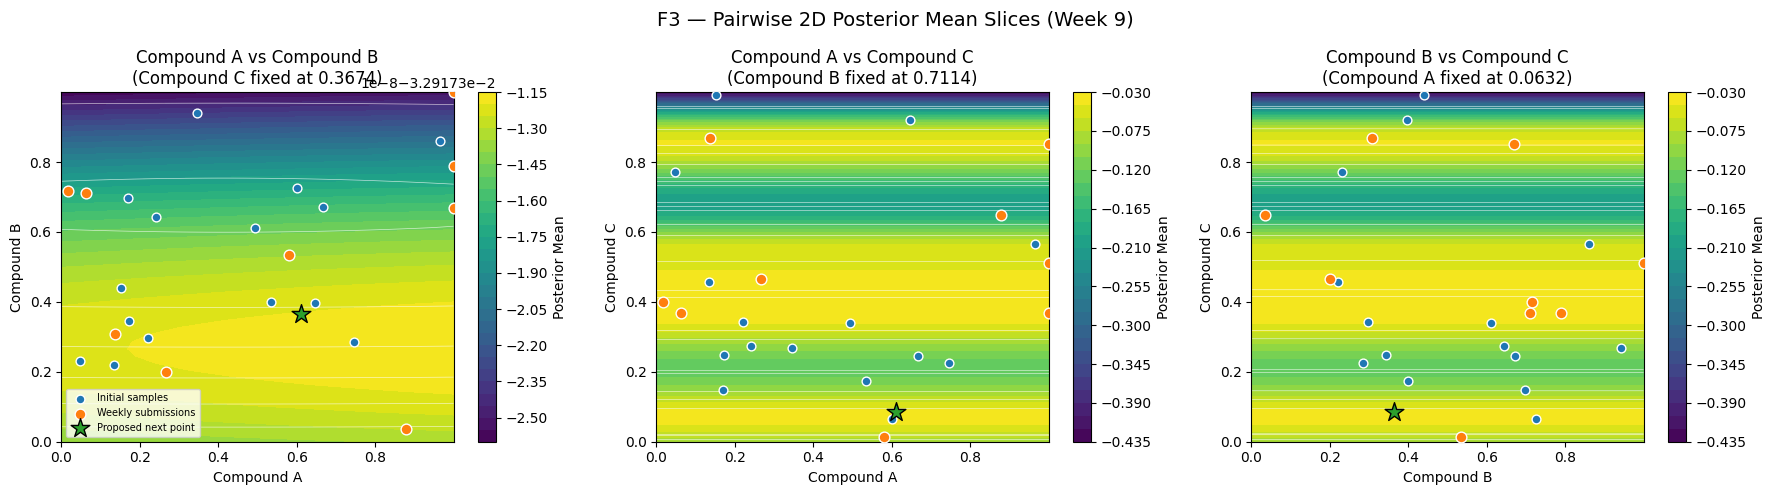

In [6]:
best_idx = y_raw.argmax()
best_point = X_raw[best_idx]

pairs = [(0, 1), (0, 2), (1, 2)]
GRID_RES = 50

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (d1, d2) in zip(axes, pairs):
    d3 = [d for d in range(DIM) if d not in (d1, d2)][0]
    
    g1 = np.linspace(0, 0.999999, GRID_RES)
    g2 = np.linspace(0, 0.999999, GRID_RES)
    G1, G2 = np.meshgrid(g1, g2)
    
    grid_points = np.full((GRID_RES * GRID_RES, DIM), best_point[d3])
    grid_points[:, d1] = G1.ravel()
    grid_points[:, d2] = G2.ravel()
    
    X_grid = torch.tensor(grid_points, dtype=torch.float64)
    
    with torch.no_grad():
        posterior = model.posterior(X_grid)
        mean_std = posterior.mean.squeeze().numpy()
        std_std  = posterior.variance.squeeze().sqrt().numpy()
    
    mean_raw = mean_std * y_std_safe + y_mean
    std_raw  = std_std * y_std_safe
    
    Mean = mean_raw.reshape(GRID_RES, GRID_RES)
    Std  = std_raw.reshape(GRID_RES, GRID_RES)
    
    c = ax.contourf(G1, G2, Mean, levels=30, cmap='viridis')
    plt.colorbar(c, ax=ax, label='Posterior Mean')
    ax.contour(G1, G2, Std, levels=5, colors='white', linewidths=0.5, alpha=0.7)
    
    # Three-colour scheme
    ax.scatter(X_initial[:, d1], X_initial[:, d2], c='tab:blue', s=40,
               edgecolors='white', zorder=5,
               label='Initial samples' if d1 == 0 and d2 == 1 else None)
    ax.scatter(X_submissions[:, d1], X_submissions[:, d2], c='tab:orange', s=60,
               edgecolors='white', zorder=5,
               label='Weekly submissions' if d1 == 0 and d2 == 1 else None)
    ax.scatter(next_x[d1], next_x[d2], c='tab:green', marker='*', s=200,
               edgecolors='black', zorder=6,
               label='Proposed next point' if d1 == 0 and d2 == 1 else None)
    
    ax.set_xlabel(DIM_NAMES[d1])
    ax.set_ylabel(DIM_NAMES[d2])
    ax.set_title(f'{DIM_NAMES[d1]} vs {DIM_NAMES[d2]}\n({DIM_NAMES[d3]} fixed at {best_point[d3]:.4f})')
    if d1 == 0 and d2 == 1:
        ax.legend(fontsize=7)

plt.suptitle('F3 — Pairwise 2D Posterior Mean Slices (Week 9)', fontsize=14)
plt.tight_layout()
plt.show()

### Step 5: Convergence Plot

Running maximum of observed values across all samples. Vertical dashed lines show phase boundaries.

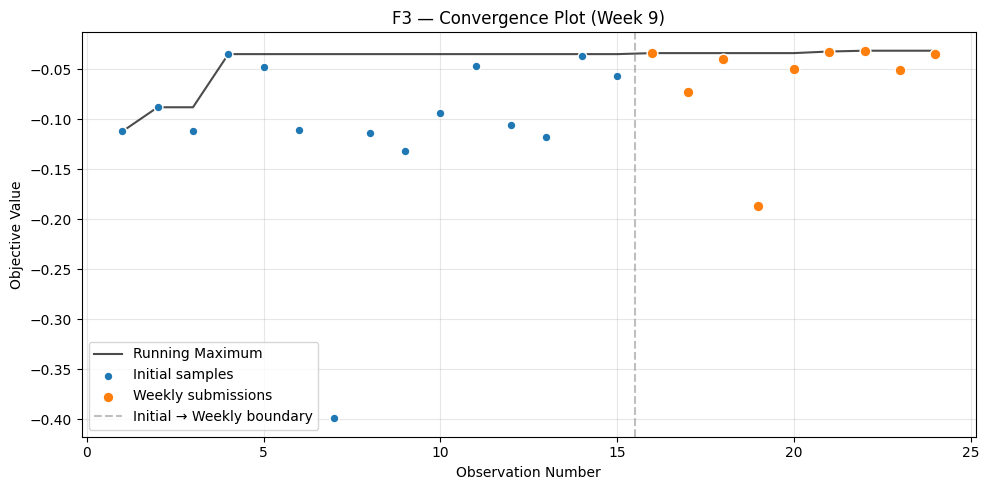

Best value: -0.031427 at observation 22
Total samples: 24
Best after initial:     -0.034835
Best after submissions: -0.031427
Submissions improved best: Yes ✓


In [7]:
# Running maximum convergence
running_max = np.maximum.accumulate(y_raw)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(y_raw) + 1), running_max, 'k-', linewidth=1.5, alpha=0.7, label='Running Maximum')

# Two-colour scheme
ax.scatter(range(1, N_INITIAL + 1), y_raw[:N_INITIAL],
           c='tab:blue', s=40, edgecolors='white', zorder=5, label='Initial samples')
ax.scatter(range(N_INITIAL + 1, N_TOTAL + 1), y_raw[N_INITIAL:],
           c='tab:orange', s=60, edgecolors='white', zorder=5, label='Weekly submissions')

ax.axvline(x=N_INITIAL + 0.5, color='gray', linestyle='--', alpha=0.5, label='Initial → Weekly boundary')
ax.set_xlabel('Observation Number')
ax.set_ylabel('Objective Value')
ax.set_title('F3 — Convergence Plot (Week 9)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best value: {y_raw.max():.6f} at observation {y_raw.argmax() + 1}")
print(f"Total samples: {len(y_raw)}")
best_initial_val = y_raw[:N_INITIAL].max()
best_final_val = y_raw.max()
print(f"Best after initial:     {best_initial_val:.6f}")
print(f"Best after submissions: {best_final_val:.6f}")
improved = best_final_val > best_initial_val
print(f"Submissions improved best: {'Yes ✓' if improved else 'No — initial best retained'}")

### Step 6: Format Submission

Clamp proposed point to [0, 0.999999] and check for duplicates in existing data.

In [8]:
# Clamp to valid range
proposed = np.clip(next_x, 0.0, 0.999999)

# Duplicate check
distances = np.linalg.norm(X_raw - proposed, axis=1)
min_dist = distances.min()
is_duplicate = min_dist < 1e-6

if is_duplicate:
    print("⚠️  WARNING: Proposed point is a near-duplicate of existing data!")
    print(f"   Closest existing point at distance {min_dist:.8f}")
else:
    print(f"✓ No duplicate (min distance to existing data: {min_dist:.6f})")

formatted_query = '-'.join(f'{v:.6f}' for v in proposed)

# Validation
parts = formatted_query.split("-")
assert len(parts) == DIM, f"Expected {DIM} dimensions, got {len(parts)}"
for p in parts:
    v = float(p)
    assert 0.0 <= v <= 0.999999, f"Value {v} out of bounds [0, 0.999999]"

print(f"\n{'='*60}")
print(f"WEEK 9 SUBMISSION QUERY FOR FUNCTION 3")
print(f"{'='*60}")
for d in range(DIM):
    print(f"  {DIM_NAMES[d]:>12}: {proposed[d]:.6f}")
print(f"\n  {formatted_query}")
print(f"{'='*60}")
print("✓ Submission format validated")

✓ No duplicate (min distance to existing data: 0.121806)

WEEK 9 SUBMISSION QUERY FOR FUNCTION 3
    Compound A: 0.611482
    Compound B: 0.364137
    Compound C: 0.085117

  0.611482-0.364137-0.085117
✓ Submission format validated


---

## Performance Evaluation

### Cell 10: Convergence Metrics

In [9]:
# ── Convergence Metrics ────────────────────────────────────────────────────────
best_initial = y_raw[:N_INITIAL].max()
best_trajectory = np.array([y_raw[:N_INITIAL + k + 1].max() for k in range(N_SUBMISSIONS)])
per_submission_delta = np.diff(np.concatenate([[best_initial], best_trajectory]))
new_best_flags = per_submission_delta > 0

tail_no_improve = 0
for flag in reversed(new_best_flags):
    if not flag:
        tail_no_improve += 1
    else:
        break
consecutive_no_improvement = tail_no_improve

best_final = y_raw.max()
improvement = best_final - best_initial
if abs(best_initial) < 1e-10:
    relative_improvement = 0.0 if improvement < 1e-10 else 1.0
else:
    relative_improvement = improvement / abs(best_initial)

stalling_flag = (consecutive_no_improvement >= STALLING_CONSECUTIVE_THRESHOLD or
                 relative_improvement < STALLING_RELATIVE_THRESHOLD)

print("=" * 60)
print("CONVERGENCE METRICS — Function 3, Week 9")
print("=" * 60)
print(f"  Best after initial samples: {best_initial:.6f}")
print(f"  Best after all submissions: {best_final:.6f}")
print(f"  Absolute improvement:       {improvement:.6f}")
print(f"  Relative improvement:       {relative_improvement:.4f} ({relative_improvement*100:.1f}%)")
print(f"  Submissions finding new best: {new_best_flags.sum()} / {N_SUBMISSIONS}")
print(f"  Trailing no-improvement streak: {consecutive_no_improvement}")
print(f"  Stalling flag: {'⚠ YES — STALLING' if stalling_flag else '✓ NO — healthy progress'}")
print()
print(f"{'Sub':>4}  {'Best After':>12}  {'Delta':>10}  {'New Best?':>10}")
print("-" * 42)
for k in range(N_SUBMISSIONS):
    marker = "✓" if new_best_flags[k] else "—"
    print(f"{k+1:>4}  {best_trajectory[k]:>12.6f}  {per_submission_delta[k]:>10.6f}  {marker:>10}")

CONVERGENCE METRICS — Function 3, Week 9
  Best after initial samples: -0.034835
  Best after all submissions: -0.031427
  Absolute improvement:       0.003408
  Relative improvement:       0.0978 (9.8%)
  Submissions finding new best: 3 / 9
  Trailing no-improvement streak: 2
  Stalling flag: ✓ NO — healthy progress

 Sub    Best After       Delta   New Best?
------------------------------------------
   1     -0.033818    0.001018           ✓
   2     -0.033818    0.000000           —
   3     -0.033818    0.000000           —
   4     -0.033818    0.000000           —
   5     -0.033818    0.000000           —
   6     -0.032221    0.001596           ✓
   7     -0.031427    0.000794           ✓
   8     -0.031427    0.000000           —
   9     -0.031427    0.000000           —


### Cell 11: Exploration Spread

For 3D inputs in [0,1]³, uniform random points have mean pairwise distance ~0.65.

In [10]:
# ── Exploration Spread Metrics ─────────────────────────────────────────────────
dists = pdist(X_submissions)
mean_pairwise = dists.mean()
dist_matrix = squareform(dists)
np.fill_diagonal(dist_matrix, np.inf)
nn_dists = dist_matrix.min(axis=1)
max_nn_dist = nn_dists.max()
min_nn_dist = nn_dists.min()

EXPECTED_UNIFORM = 0.65  # Approx for 3D [0,1]^3

print("=" * 60)
print("EXPLORATION SPREAD — Function 3, Week 9")
print("=" * 60)
print(f"  Number of submissions:        {N_SUBMISSIONS}")
print(f"  Mean pairwise distance:       {mean_pairwise:.4f}  (uniform 3D ≈ {EXPECTED_UNIFORM})")
print(f"  Max nearest-neighbour dist:   {max_nn_dist:.4f}")
print(f"  Min nearest-neighbour dist:   {min_nn_dist:.4f}  (tightest cluster)")
clustered = mean_pairwise < EXPECTED_UNIFORM * 0.7
print(f"  Clustering detected:          {'⚠ YES' if clustered else '✓ No'}")

EXPLORATION SPREAD — Function 3, Week 9
  Number of submissions:        9
  Mean pairwise distance:       0.7999  (uniform 3D ≈ 0.65)
  Max nearest-neighbour dist:   0.6611
  Min nearest-neighbour dist:   0.0573  (tightest cluster)
  Clustering detected:          ✓ No


### Cell 12: LOO Surrogate Error — SFGP with Z-Score Recomputation

For each fold, recompute z-score stats (mean, std) on the LOO training set before fitting. Un-standardise predictions before computing error in raw output space.

In [11]:
# ── LOO Cross-Validation (9 folds) — SFGP Matérn-2.5 with z-score recomputation ──
loo_predictions = []
loo_actuals = []
loo_errors = []

print(f"{'Fold':>5}  {'Held-Out':>9}  {'Actual':>10}  {'Predicted':>10}  {'Error':>10}")
print("-" * 50)

for fold in range(N_SUBMISSIONS):
    held_out_idx = N_INITIAL + fold

    mask = np.ones(N_TOTAL, dtype=bool)
    mask[held_out_idx] = False
    X_loo = X_raw[mask]
    y_loo = y_raw[mask]

    # Recompute z-score for this fold
    y_loo_mean = y_loo.mean()
    y_loo_std = max(y_loo.std(), 1e-8)
    y_loo_std_z = (y_loo - y_loo_mean) / y_loo_std

    X_loo_t = torch.tensor(X_loo, dtype=torch.float64)
    Y_loo_t = torch.tensor(y_loo_std_z, dtype=torch.float64).unsqueeze(-1)

    # Retrain with 5 restarts (reduced for speed)
    best_loo_loss = float('inf')
    best_loo_model = None
    for seed in range(5):
        torch.manual_seed(seed + 200)
        lik = GaussianLikelihood(noise_constraint=GreaterThan(JITTER))
        covar = ScaleKernel(MaternKernel(nu=2.5, ard_num_dims=DIM))
        m = SingleTaskGP(train_X=X_loo_t, train_Y=Y_loo_t,
                         covar_module=covar, likelihood=lik).double()
        m.covar_module.base_kernel.lengthscale = LENGTHSCALE_INIT
        m.covar_module.outputscale = SIGNAL_VAR_INIT
        m.likelihood.noise = NOISE_VAR_INIT
        mll_loo = ExactMarginalLogLikelihood(lik, m)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fit_gpytorch_mll(mll_loo)
        m.eval(); lik.eval()
        with torch.no_grad():
            out = m(X_loo_t)
            loss = -mll_loo(out, m.train_targets).item()
        if loss < best_loo_loss:
            best_loo_loss = loss
            best_loo_model = copy.deepcopy(m)

    # Predict held-out in standardised space, then de-standardise
    x_held = torch.tensor(X_raw[held_out_idx:held_out_idx+1], dtype=torch.float64)
    best_loo_model.eval()
    with torch.no_grad():
        pred_std = best_loo_model.posterior(x_held).mean.item()
    pred_raw = pred_std * y_loo_std + y_loo_mean  # Un-standardise

    actual = y_raw[held_out_idx]
    error = abs(pred_raw - actual)
    loo_predictions.append(pred_raw)
    loo_actuals.append(actual)
    loo_errors.append(error)
    print(f"{fold+1:>5}  {held_out_idx:>9}  {actual:>10.6f}  {pred_raw:>10.6f}  {error:>10.6f}")

loo_errors = np.array(loo_errors)
loo_mae = loo_errors.mean()
loo_rmse = np.sqrt((loo_errors**2).mean())

print(f"\n{'='*50}")
print(f"LOO SURROGATE ERROR — Function 3 (SFGP Matérn-2.5, z-score recomputed)")
print(f"{'='*50}")
print(f"  MAE:  {loo_mae:.6f}")
print(f"  RMSE: {loo_rmse:.6f}")
print(f"  Max error:  {loo_errors.max():.6f} (fold {loo_errors.argmax()+1})")
print(f"  Min error:  {loo_errors.min():.6f} (fold {loo_errors.argmin()+1})")
print(f"  Note: 9-fold LOO with z-score recomputation per fold")

 Fold   Held-Out      Actual   Predicted       Error
--------------------------------------------------


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning:

    1         15   -0.033818   -0.032261    0.001557


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning:

    2         16   -0.072569   -0.053354    0.019215


...

/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning:

    6         20   -0.032221   -0.032656    0.000435


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning:

    7         21   -0.031427   -0.033603    0.002176
    8         22   -0.050946   -0.038887    0.012059
    9         23   -0.034361   -0.030641    0.003721

LOO SURROGATE ERROR — Function 3 (SFGP Matérn-2.5, z-score recomputed)
  MAE:  0.020443
  RMSE: 0.033353
  Max error:  0.078276 (fold 4)
  Min error:  0.000435 (fold 6)
  Note: 9-fold LOO with z-score recomputation per fold


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning:

### Cell 13: Interpretation & Strategy Recommendations

**Convergence Assessment**:  
Review the stalling flag above. If stalling, the SFGP Matérn-2.5 with manual z-score may need refinement.

**Exploration Spread**:  
For 3D inputs in [0,1]³, uniform random points give mean pairwise distance ≈ 0.65. Values below 0.45 suggest clustering.

**LOO Surrogate Accuracy**:  
The LOO MAE/RMSE indicate how well the SFGP predicts held-out submissions. Z-score recomputation per fold ensures unbiased evaluation.

**If stalling, consider these strategy changes for Week 10**:
1. **Use BoTorch Standardize(m=1) instead of manual z-score** — eliminates manual recomputation and ensures consistent normalisation
2. **Increase acquisition num_restarts from 10 to 20** — broader acquisition search for better candidates
3. **Add interior penalty (S=0.5, F=0.01)** — encourage exploration away from boundaries

**If not stalling**: Continue with the current SFGP Matérn-2.5 + qLogNEI strategy.